In [1]:
from sklearn.datasets import fetch_openml

In [9]:
fashion = fetch_openml('fashion-mnist',version=1)

In [10]:
fashion.keys

<function Bunch.keys>

In [11]:
X,y =fashion['data'],fashion['target']

In [12]:
X.shape

(70000, 784)

In [18]:
X_train,X_test,y_train,y_test = X[:20000],X[60000:],y[:20000],y[60000:]

In [14]:
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=42)

In [19]:
model.fit(X_train,y_train)

SGDClassifier(random_state=42)

In [23]:
model.predict(X[:100])

array(['9', '0', '0', '0', '0', '2', '7', '2', '5', '5', '0', '9', '5',
       '5', '7', '9', '1', '0', '2', '4', '3', '1', '2', '8', '2', '0',
       '0', '2', '2', '4', '5', '3', '6', '6', '0', '8', '5', '2', '1',
       '6', '6', '7', '9', '5', '9', '2', '7', '0', '0', '3', '3', '0',
       '7', '2', '2', '0', '0', '8', '3', '3', '5', '0', '5', '6', '0',
       '2', '0', '0', '4', '1', '0', '1', '0', '3', '1', '4', '2', '0',
       '1', '9', '1', '3', '5', '7', '9', '7', '1', '7', '9', '9', '9',
       '0', '0', '9', '0', '6', '4', '1', '1', '8'], dtype='<U1')

In [58]:
import cv2
import numpy as np

# carrega a imagen
image_path = '/content/105186615.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Redefine a imagem para 28x28 pixels
img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)

# transforma para um array 1D
img_flattened = img_resized.flatten()

# Redefine a imagem para um array 2D
img_input = img_resized.reshape(1, -1)

img_label = model.predict(img_input)[0]

print(f"O rotulo para esta imagen e: {img_label[0]}")

O rotulo para esta imagen e: 8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


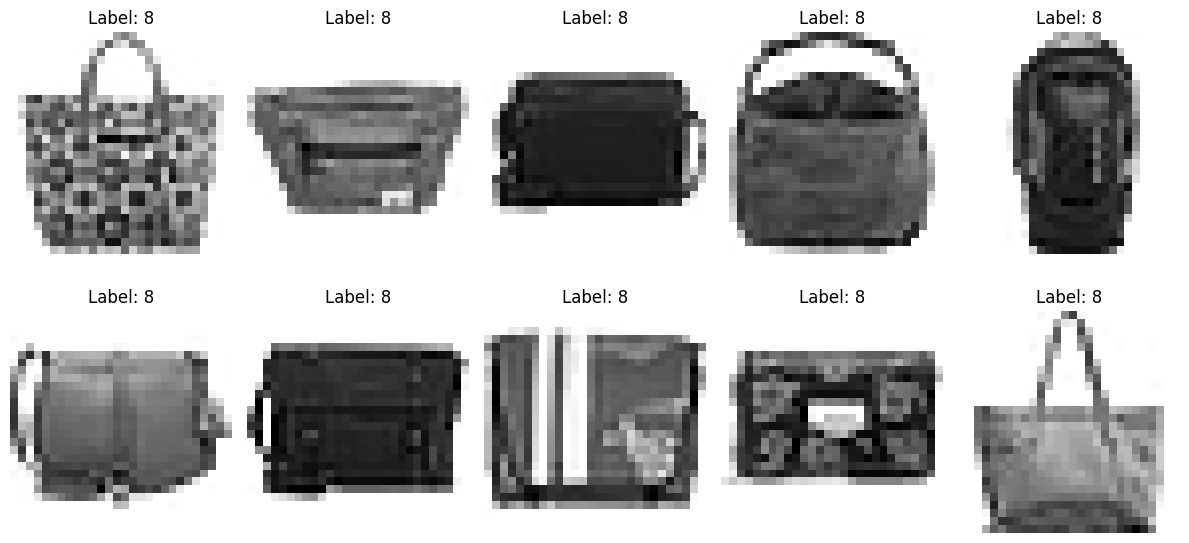

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Get the predicted label from the previous cell
label = img_label

# Find indices of images with the predicted label
indices_label = y[y == label].index

# Select up to 10 random indices from the found indices
num_imagems = min(len(indices_label), 10)
random_indices = np.random.choice(indices_label, size=num_imagems, replace=False)

# Display the imagens
plt.figure(figsize=(12, 6))
for i, index in enumerate(random_indices):
    image_data = X.iloc[index].values.reshape(28, 28)
    true_label = y.iloc[index]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_data, cmap='binary')
    plt.title(f"Label: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()